<a href="https://colab.research.google.com/github/jagdish1013/decodelabs_tasks/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from scipy.stats import zscore

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    RobustScaler
)

In [ ]:
DATA_PATH = "train.csv"

df = pd.read_csv(DATA_PATH)

print("="*50)
print("DATASET SHAPE")
print(df.shape)
print("="*50)

DATASET SHAPE
(1460, 81)


In [ ]:
print("\nDATA INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nSTATISTICAL SUMMARY")
print(df.describe())



DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [ ]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records : {duplicates}")



Duplicate Records : 0


In [ ]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    include='object'
).columns.tolist()

print("\nNumerical Features :", len(numerical_cols))
print("Categorical Features :", len(categorical_cols))



Numerical Features : 38
Categorical Features : 43


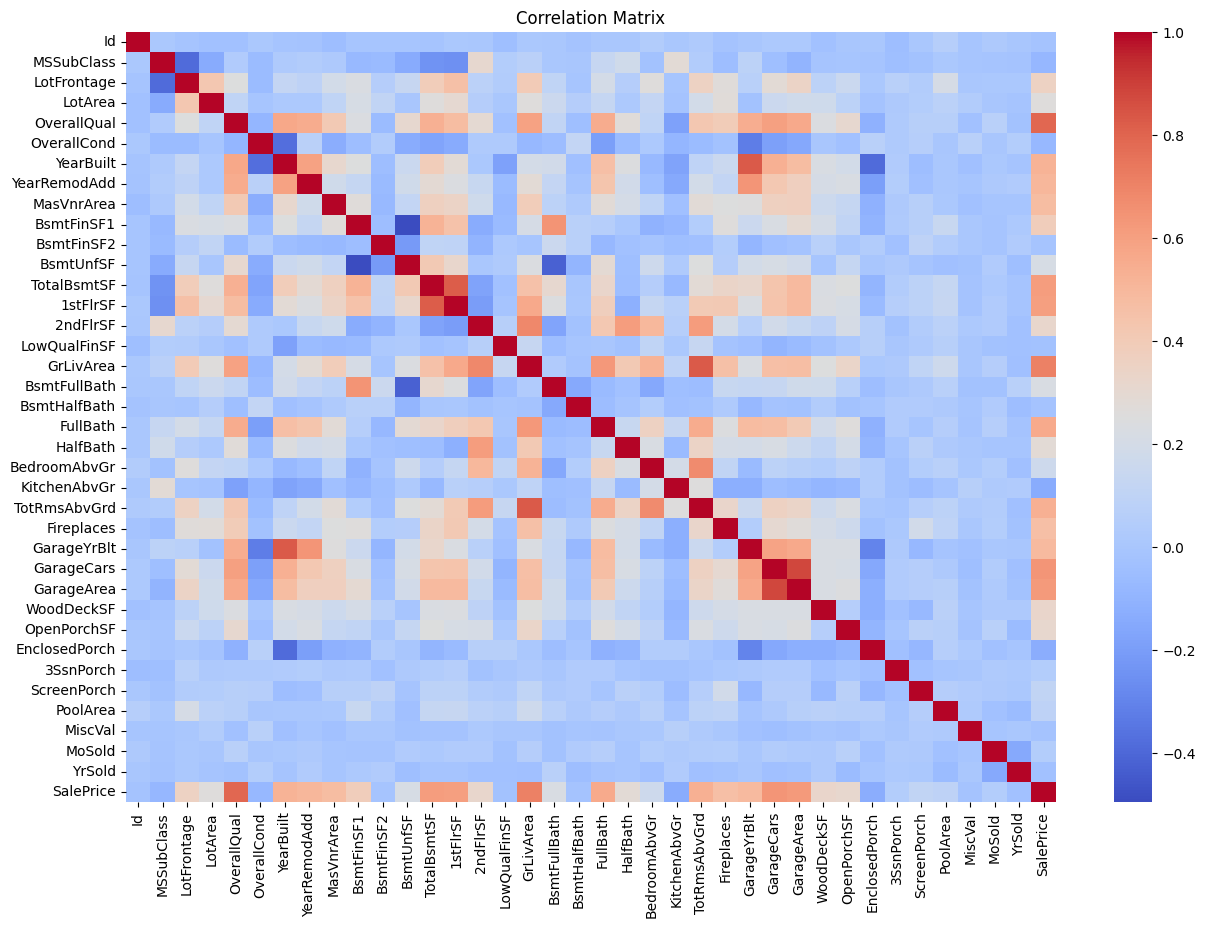

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
missing_percent = (
    df.isnull().sum()
    /
    len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing %': missing_percent
})

print(
    missing_df[
        missing_df['Missing %'] > 0
    ].sort_values(
        by='Missing %',
        ascending=False
    )
)

              Missing %
PoolQC        99.520548
MiscFeature   96.301370
Alley         93.767123
Fence         80.753425
MasVnrType    59.726027
FireplaceQu   47.260274
LotFrontage   17.739726
GarageType     5.547945
GarageYrBlt    5.547945
GarageFinish   5.547945
GarageQual     5.547945
GarageCond     5.547945
BsmtExposure   2.602740
BsmtFinType2   2.602740
BsmtQual       2.534247
BsmtCond       2.534247
BsmtFinType1   2.534247
MasVnrArea     0.547945
Electrical     0.068493


In [ ]:
outlier_summary = {}

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower)
        |
        (df[col] > upper)
    ).sum()
    outlier_summary[col] = outliers

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=['Feature','Outliers']
)

print(
    outlier_df.sort_values(
        by='Outliers',
        ascending=False
    ).head(15)
)

          Feature  Outliers
30  EnclosedPorch       208
10     BsmtFinSF2       167
5     OverallCond       125
32    ScreenPorch       116
1      MSSubClass       103
8      MasVnrArea        96
2     LotFrontage        88
18   BsmtHalfBath        82
29    OpenPorchSF        77
3         LotArea        69
22   KitchenAbvGr        68
12    TotalBsmtSF        61
37      SalePrice        61
34        MiscVal        52
21   BedroomAbvGr        35


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineering(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # House Age
        X["HouseAge"] = X["YrSold"] - X["YearBuilt"]

        # Remodel Age
        X["RemodelAge"] = X["YrSold"] - X["YearRemodAdd"]

        # Total Bathrooms
        X["TotalBathrooms"] = (
            X["FullBath"]
            + 0.5 * X["HalfBath"]
            + X["BsmtFullBath"]
            + 0.5 * X["BsmtHalfBath"]
        )

        # Total Area
        X["TotalArea"] = (
            X["TotalBsmtSF"]
            + X["1stFlrSF"]
            + X["2ndFlrSF"]
        )

        # Total Porch Area
        X["TotalPorchArea"] = (
            X["OpenPorchSF"]
            + X["EnclosedPorch"]
            + X["3SsnPorch"]
            + X["ScreenPorch"]
        )

        # Quality Score
        X["QualityScore"] = (
            X["OverallQual"]
            * X["OverallCond"]
        )

        # Garage Age
        X["GarageAge"] = (
            X["YrSold"]
            - X["GarageYrBlt"]
        )

        # Room Density
        X["RoomDensity"] = (
            X["TotRmsAbvGrd"]
            / (X["GrLivArea"] + 1)
        )

        # Luxury Index
        X["LuxuryIndex"] = (
            X["OverallQual"]
            * X["GrLivArea"]
        )

        return X

In [ ]:
num_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = df.select_dtypes(
    include='object'
).columns.tolist()

numeric_pipeline = Pipeline([
    (
        "imputer",
        KNNImputer(
            n_neighbors=5
        )
    ),
    (
        "scaler",
        RobustScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy='most_frequent'
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        num_cols
    ),
    (
        "cat",
        categorical_pipeline,
        cat_cols
    )
])


In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        self.lower_bounds = {}
        self.upper_bounds = {}

        for col in X.columns:

            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)

            IQR = Q3 - Q1

            self.lower_bounds[col] = (
                Q1 - 1.5 * IQR
            )

            self.upper_bounds[col] = (
                Q3 + 1.5 * IQR
            )

        return self

    def transform(self, X):

        X = X.copy()

        for col in X.columns:

            X[col] = np.clip(
                X[col],
                self.lower_bounds[col],
                self.upper_bounds[col]
            )

        return X

In [ ]:

def remove_multicollinearity(data,threshold=0.80):

    corr_matrix = (
        data.corr()
        .abs()
    )

    upper = corr_matrix.where(
        np.triu(
            np.ones(
                corr_matrix.shape
            ),
            k=1
        ).astype(bool)
    )

    drop_cols = [
        column
        for column in upper.columns
        if any(
            upper[column] > threshold
        )
    ]

    data = data.drop(
        columns=drop_cols,
        errors='ignore'
    )

    return data

In [ ]:
feature_engineer = FeatureEngineering()

df = feature_engineer.fit_transform(df)

target = "SalePrice"

X = df.drop(
    columns=[target, 'Id']
)

y = df[target]


num_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X.select_dtypes(
    include='object'
).columns.tolist()


winsor = Winsorizer()
numeric_X = X[num_cols].copy()
numeric_X = winsor.fit_transform(
    numeric_X
)
X[num_cols] = numeric_X



numeric_pipeline = Pipeline([
    (
        "imputer",
        KNNImputer(
            n_neighbors=5
        )
    ),
    (
        "scaler",
        RobustScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy='most_frequent'
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        num_cols
    ),
    (
        "cat",
        categorical_pipeline,
        cat_cols
    )
])


processed_data = preprocessor.fit_transform(X)


processed_df = pd.DataFrame(processed_data)

selector = VarianceThreshold(
    threshold=0.01
)

processed_df = pd.DataFrame(
    selector.fit_transform(
        processed_df
    )
)


processed_df = remove_multicollinearity(
    processed_df,
    threshold=0.80
)

processed_df["SalePrice"] = y.values

In [ ]:
print("\nFINAL FEATURE STORE SHAPE")
print(processed_df.shape)

print("\nMISSING VALUES")
print(
    processed_df.isnull()
    .sum()
    .sum()
)

print("\nDUPLICATES")
print(
    processed_df.duplicated()
    .sum()
)


FINAL FEATURE STORE SHAPE
(1460, 164)

MISSING VALUES
0

DUPLICATES
0


In [ ]:
FEATURE_STORE_PATH = (
    "house_price_feature_store.csv"
)

processed_df.to_csv(
    FEATURE_STORE_PATH,
    index=False
)

print(
    "\nFeature Store Saved Successfully"
)

print(
    f"\nPath : {FEATURE_STORE_PATH}"
)


Feature Store Saved Successfully

Path : house_price_feature_store.csv
